In [11]:
import numpy as np
import matplotlib.pyplot as plt
import random
from numba import njit
from time import time
from numpy import math
from tqdm import tqdm
import warnings

In [12]:
t1 = time()
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [13]:
ensemble_num = 1
n = 50             # number of nodes (arbitrary)
step_mc = 6*(n**2)   # number of monte carlo steps

In [14]:
#network

def Network_maker1(N): # negative and positive link
    negative_network = -np.ones((N, N))
    np.fill_diagonal(negative_network, 0)

    positive_network = np.ones((N, N))
    np.fill_diagonal(positive_network, 0)
    
    return negative_network, positive_network

In [15]:
def Network_maker2(N): # random link network
    random_network= np.random.choice([-1, 1], size=(n, n))
    random_network = np.triu(random_network, 1)
    random_network = random_network + random_network.T
    np.fill_diagonal(random_network, 0)
    return random_network

In [16]:
negative_network, positive_network = Network_maker1(n)
random_network = Network_maker2(n)

In [17]:
num_of_triangels = (n*(n-1)*(n-2)/6) # number of triangles in a fully connected network

In [18]:
@njit
def Energy(network,N):
    S = 0 # weight of all triangles in the network
    for i in range(N):
        for j in range(i):
            for k in range(j):
                S += network[i,j]*network[j,k]*network[k,i]
    e = -S/num_of_triangels #energy                
    return e                

In [19]:
def monte_carlo_simulation(Network, N, ensemble_num, step_mc):

    Temp = []
    energy = []

    for T in tqdm(np.arange(0.001, 40, 0.1)):

        ensemble_E = []

        for ens in range(ensemble_num):

            network = Network.copy()

            for mc in range(step_mc):

                # picking a link randomly
                i, j = np.random.choice(N, 2, replace=False)

                # ΔE calculation
                s = 0
                for k in range(N):
                    s += network[j, k] * network[k, i]

                delta_E = 2 * network[i, j] * s

                
                if np.random.rand() < min(1, np.exp(-delta_E / T)):
                    network[i, j] *= -1
                    network[j, i] *= -1

            ensemble_E.append(Energy(network, N))

        Temp.append(T)
        energy.append(np.mean(ensemble_E))

    return Temp, energy

In [20]:
Temp,pos_energy= monte_carlo_simulation(positive_network,n, ensemble_num, step_mc)
Temp,neg_energy= monte_carlo_simulation(negative_network,n, ensemble_num, step_mc)
Temp,rand_energy= monte_carlo_simulation(random_network,n, ensemble_num, step_mc)

100%|██████████| 400/400 [03:35<00:00,  1.86it/s]


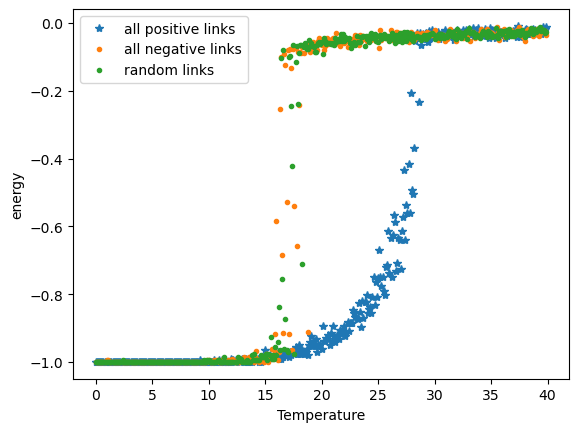

In [21]:
plt.plot(Temp,pos_energy,'*', label = 'all positive links' )
plt.plot(Temp,neg_energy,'.', label = 'all negative links' )
plt.plot(Temp,rand_energy,'.', label = 'random links' )
plt.ylabel('energy')
plt.xlabel('Temperature')
plt.legend()
plt.show()